# 404 — Matrices de confusión normalizadas por porcentaje

**Corrección de jurado C #16**

Regenera las matrices de confusión de los seis modelos finales en versión porcentual sobre el conjunto de prueba (split\_id = 3), y documenta la diferencia de tamaño efectivo entre arquitecturas.

**Salidas:**
- `reports/figures/confusion_matrices_pct/confusion_matrices_pct.{png,pdf}`
- `reports/figures/confusion_matrices_pct/confusion_matrices_pct_summary.{csv,md}`
- `reports/figures/confusion_matrices_pct/pixel_reduction_table.csv`

## Librerías

In [1]:
import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

## 0. Imports y configuración

In [3]:
import os, sys, json, warnings
# sys.stdout.reconfigure(encoding="utf-8")
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score,
)
warnings.filterwarnings("ignore")
%matplotlib inline


In [4]:
package_path = os.path.abspath("..").split(os.sep + "notebooks")[0]
if package_path not in sys.path:
    sys.path.insert(0, package_path)

from spectralcrop.utils.path_manager import PathManager

PM = PathManager()

def _resolve(p):
    if isinstance(p, list):
        return [x for x in p if "spectralcrop" not in x][0]
    return p

INTERIM_PATH   = _resolve(PM.get_abs_path_folder("interim"))
PROCESSED_PATH = _resolve(PM.get_abs_path_folder("processed"))
MODELS_PATH    = Path(_resolve(PM.get_abs_path_folder("models")))
REPORTS_PATH   = _resolve(PM.get_abs_path_folder("reports"))

ZARR_PATH   = INTERIM_PATH + "masked_reflectance.zarr"
LABELS_PATH = _resolve(PM.get_abs_path_file("labels_multiclass.tif"))
SPLIT_PATH  = PROCESSED_PATH + "/splits/by_plot_split_id_binary.tif"
BANDS_PATH  = _resolve(PM.get_abs_path_file("bands_selected_by_segment.csv"))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"ZARR   : {ZARR_PATH}")
print(f"Models : {MODELS_PATH}")


Device : cuda
ZARR   : c:\Users\mario\Documentos\personal_projects\thesis\data\interim\masked_reflectance.zarr
Models : c:\Users\mario\Documentos\personal_projects\thesis\models


In [5]:
FIGS_CM = Path(REPORTS_PATH) / "figures" / "confusion_matrices_pct"
FIGS_CM.mkdir(parents=True, exist_ok=True)
print(f"Output: {FIGS_CM}")


Output: c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\confusion_matrices_pct


## 1. Arquitecturas DL

In [6]:
class Spectral1DCNN(nn.Module):
    def __init__(self, n_classes=2, kernel_size=5, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(1, 16, kernel_size=kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool  = nn.AdaptiveAvgPool1d(8)
        self.fc1   = nn.Linear(32 * 8, 64)
        self.drop  = nn.Dropout(dropout)
        self.fc2   = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


class SpectralSpatialCNN2D(nn.Module):
    def __init__(self, n_channels=63, n_classes=2, dropout=0.3, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(n_channels, 32, kernel_size=kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, padding=pad)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.AdaptiveAvgPool2d((2, 2))
        self.fc1   = nn.Linear(128 * 2 * 2, 128)
        self.drop  = nn.Dropout(dropout)
        self.fc2   = nn.Linear(128, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


## 2. Carga de datos

> **Feature layout:** posiciones 0–4 = VI (NDVI, NDRE, CIgreen, PRI, PSRI); posiciones 5–62 = 58 bandas espectrales.

In [7]:
# Feature layout (63 channels):
#   0-4  : NDVI, NDRE, CIgreen, PRI, PSRI
#   5-62 : 58 selected spectral bands

ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})

bands_df       = pd.read_csv(BANDS_PATH)
selected_bands = bands_df["band_index"].tolist()
assert len(selected_bands) == 58

indices_da           = ds[["NDVI", "NDRE", "CIgreen", "PRI", "PSRI"]].to_array(dim="band")
reflectance_selected = ds["reflectance"].isel(band=selected_bands)
features_stack       = xr.concat([indices_da, reflectance_selected], dim="band")
features_stack       = features_stack.transpose("y", "x", "band")

VI_NAMES     = ["NDVI", "NDRE", "CIgreen", "PRI", "PSRI"]
VI_INDICES   = list(range(5))
SPECTRAL_IDX = list(range(5, 63))

print(f"Feature cube: {features_stack.sizes}")

# Labels: 0=non-stressed, 1=stressed, NaN=invalid
with rasterio.open(LABELS_PATH) as src:
    labels_raw = src.read(1)
labels_bin = np.where(labels_raw == 0, 0,
             np.where(np.isin(labels_raw, [1, 2, 3]), 1, np.nan))

# Split map: 1=train, 2=val, 3=test
with rasterio.open(SPLIT_PATH) as src:
    split_map = src.read(1)

print("Loading feature cube into memory...")
X_cube = features_stack.values  # (H, W, 63)
H, W, B = X_cube.shape

X_flat      = X_cube.reshape(-1, B)
labels_flat = labels_bin.reshape(-1, 1)
split_flat  = np.where(split_map == 0, np.nan, split_map.astype(float)).reshape(-1, 1)
data_full   = np.concatenate([X_flat, labels_flat, split_flat], axis=1)

df_full = pd.DataFrame(data_full).dropna(axis=0, how="any")
df_full.rename(columns={df_full.columns[-2]: "label",
                         df_full.columns[-1]: "split"}, inplace=True)

X_all     = df_full.drop(columns=["label", "split"]).values
y_all     = df_full["label"].values
split_all = df_full["split"].values

X_train = X_all[split_all == 1];  y_train = y_all[split_all == 1]
X_val   = X_all[split_all == 2];  y_val   = y_all[split_all == 2]
X_test  = X_all[split_all == 3];  y_test  = y_all[split_all == 3]

print(f"train={len(X_train):,}  val={len(X_val):,}  test={len(X_test):,}")
print(f"test: 0={int((y_test==0).sum()):,}  1={int((y_test==1).sum()):,}")


Feature cube: Frozen({'y': 3660, 'x': 3438, 'band': 63})
Loading feature cube into memory...
train=1,009,179  val=343,275  test=361,810
test: 0=92,596  1=269,214


## 3. Escalado + parches CNN-2D (test)

> El bucle anidado sobre la imagen puede tardar varios minutos.

In [8]:
scaler_ext     = joblib.load(MODELS_PATH / "robust_scaler.pkl")
X_train_scaled = scaler_ext.transform(X_train)
X_val_scaled   = scaler_ext.transform(X_val)
X_test_scaled  = scaler_ext.transform(X_test)

print("Scaling feature cube...")
cube_scaled = scaler_ext.transform(X_cube.reshape(-1, B)).reshape(H, W, B)

# Training-set means used for ablation neutralisation
TRAIN_MEAN_SCALED = X_train_scaled.mean(axis=0)
TRAIN_MEAN_ORIG   = X_train.mean(axis=0)


def build_patch_dataset(cube, labels_2d, split_2d, split_value, patch=5):
    """Extract CNN-2D patches. Border and NaN-neighbourhood pixels excluded."""
    Hc, Wc, Bc = cube.shape
    r = patch // 2
    X_list, y_list = [], []
    for i in range(r, Hc - r):
        for j in range(r, Wc - r):
            if split_2d[i, j] != split_value:
                continue
            if np.isnan(labels_2d[i, j]):
                continue
            patch_cube = cube[i-r:i+r+1, j-r:j+r+1, :]
            if np.isnan(patch_cube).any():
                continue
            X_list.append(np.transpose(patch_cube, (2, 0, 1)))
            y_list.append(labels_2d[i, j])
    return np.stack(X_list), np.array(y_list, dtype=np.int64)


PATCH = 5
print("Building CNN-2D test patches (may take several minutes)...")
X_test2d, y_test2d = build_patch_dataset(cube_scaled, labels_bin, split_map, 3, PATCH)
print(f"test2d={len(X_test2d):,}  "
      f"(0={int((y_test2d==0).sum()):,}, 1={int((y_test2d==1).sum()):,})")


Scaling feature cube...
Building CNN-2D test patches (may take several minutes)...
test2d=251,856  (0=60,116, 1=191,740)


## 4. Carga de modelos finales

In [9]:
ml_files = {
    "LogisticRegression": "logreg_cv_final_model.pkl",
    "SGDClassifier":      "sgd_cv_final_model.pkl",
    "LightGBM":           "lgbm_cv_final_model.pkl",
    "XGBoost":            "xgboost_cv_final_model.pkl",
}
ml_models = {n: joblib.load(MODELS_PATH / f) for n, f in ml_files.items()}

with open(MODELS_PATH / "cnn1d_final_model_info.json") as f:
    info1d = json.load(f)
model1d = Spectral1DCNN(n_classes=2, kernel_size=info1d["kernel_size"],
                         dropout=info1d["dropout"]).to(DEVICE)
model1d.load_state_dict(torch.load(MODELS_PATH / "cnn1d_final_model_weights.pt",
                                    map_location=DEVICE, weights_only=False))
model1d.eval()
THR_1D = info1d["best_thr"]

with open(MODELS_PATH / "cnn2d_final_model_info.json") as f:
    info2d = json.load(f)
model2d = SpectralSpatialCNN2D(n_channels=info2d["n_channels"], n_classes=2,
                                kernel_size=info2d["kernel_size"],
                                dropout=info2d["dropout"]).to(DEVICE)
model2d.load_state_dict(torch.load(MODELS_PATH / "cnn2d_final_model_weights.pt",
                                    map_location=DEVICE, weights_only=False))
model2d.eval()
THR_2D = info2d["best_thr"]

print("Models loaded")
print(f"  CNN-1D thr={THR_1D:.4f}  CNN-2D thr={THR_2D:.4f}")


Models loaded
  CNN-1D thr=0.4505  CNN-2D thr=0.3218


## 5. Umbrales y predicciones sobre el conjunto de prueba

In [10]:
def find_best_thr(y_true, y_prob):
    grid = np.linspace(0.10, 0.90, 161)
    return float(max(grid, key=lambda t: f1_score(y_true, (y_prob >= t).astype(int),
                                                   average="macro")))

def predict_proba_1d(model, X, batch_size=512):
    model.eval()
    probs = []
    Xt = torch.from_numpy(X.astype(np.float32)).unsqueeze(1)
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            probs.extend(torch.softmax(model(Xt[i:i+batch_size].to(DEVICE)), 1)[:, 1].cpu().numpy())
    return np.array(probs)

def predict_proba_2d(model, X, batch_size=256):
    model.eval()
    probs = []
    Xt = torch.from_numpy(X.astype(np.float32))
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            probs.extend(torch.softmax(model(Xt[i:i+batch_size].to(DEVICE)), 1)[:, 1].cpu().numpy())
    return np.array(probs)

MODEL_ORDER = ["LogisticRegression", "SGDClassifier", "LightGBM", "XGBoost", "CNN-1D", "CNN-2D"]

ml_thresholds = {}
for name, pipe in ml_models.items():
    p_val = pipe.predict_proba(X_val)[:, 1]
    ml_thresholds[name] = find_best_thr(y_val, p_val)
    print(f"  {name}: thr={ml_thresholds[name]:.4f}")

ml_probs_test = {n: p.predict_proba(X_test)[:, 1] for n, p in ml_models.items()}
ml_preds_test = {n: (p >= ml_thresholds[n]).astype(int) for n, p in ml_probs_test.items()}

p_test_1d = predict_proba_1d(model1d, X_test_scaled)
y_pred_1d = (p_test_1d >= THR_1D).astype(int)

p_test_2d = predict_proba_2d(model2d, X_test2d)
y_pred_2d = (p_test_2d >= THR_2D).astype(int)

all_probs = {**ml_probs_test, "CNN-1D": p_test_1d, "CNN-2D": p_test_2d}
all_preds = {**ml_preds_test, "CNN-1D": y_pred_1d, "CNN-2D": y_pred_2d}
all_ytrue = {m: y_test for m in MODEL_ORDER[:5]}; all_ytrue["CNN-2D"] = y_test2d
all_thr   = {**ml_thresholds, "CNN-1D": THR_1D, "CNN-2D": THR_2D}

print("\nTest-set sizes:")
for m in MODEL_ORDER:
    print(f"  {m}: {len(all_ytrue[m]):,}")


  LogisticRegression: thr=0.4450
  SGDClassifier: thr=0.4350
  LightGBM: thr=0.6950
  XGBoost: thr=0.4500

Test-set sizes:
  LogisticRegression: 361,810
  SGDClassifier: 361,810
  LightGBM: 361,810
  XGBoost: 361,810
  CNN-1D: 361,810
  CNN-2D: 251,856


## 6. C #16 — Matrices de confusión

In [11]:
CLASS_LABELS = ["Sano (0)", "Estresado (1)"]
cms_abs = {}
cms_row = {}  # recall per class — what the jury requested

for m in MODEL_ORDER:
    cm = confusion_matrix(all_ytrue[m], all_preds[m])
    cms_abs[m] = cm
    cms_row[m] = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    tn, fp, fn, tp = cm.ravel()
    pr_auc = average_precision_score(all_ytrue[m], all_probs[m])
    print(f"  {m}  (n={len(all_ytrue[m]):,})")
    print(f"    TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(f"    Recall sano={cms_row[m][0,0]:.2f}%  Recall estresado={cms_row[m][1,1]:.2f}%")
    print(f"    PR-AUC={pr_auc:.4f}")
    print()


  LogisticRegression  (n=361,810)
    TN=34,946  FP=57,650  FN=88,346  TP=180,868
    Recall sano=37.74%  Recall estresado=67.18%
    PR-AUC=0.7902

  SGDClassifier  (n=361,810)
    TN=32,725  FP=59,871  FN=83,318  TP=185,896
    Recall sano=35.34%  Recall estresado=69.05%
    PR-AUC=0.7885

  LightGBM  (n=361,810)
    TN=9,006  FP=83,590  FN=23,605  TP=245,609
    Recall sano=9.73%  Recall estresado=91.23%
    PR-AUC=0.7824

  XGBoost  (n=361,810)
    TN=38,487  FP=54,109  FN=75,356  TP=193,858
    Recall sano=41.56%  Recall estresado=72.01%
    PR-AUC=0.8236

  CNN-1D  (n=361,810)
    TN=41,758  FP=50,838  FN=75,097  TP=194,117
    Recall sano=45.10%  Recall estresado=72.11%
    PR-AUC=0.8341

  CNN-2D  (n=251,856)
    TN=40,254  FP=19,862  FN=21,847  TP=169,893
    Recall sano=66.96%  Recall estresado=88.61%
    PR-AUC=0.9635



### 6.1 Figura editorial — 3 filas × 2 columnas (ejes compartidos)

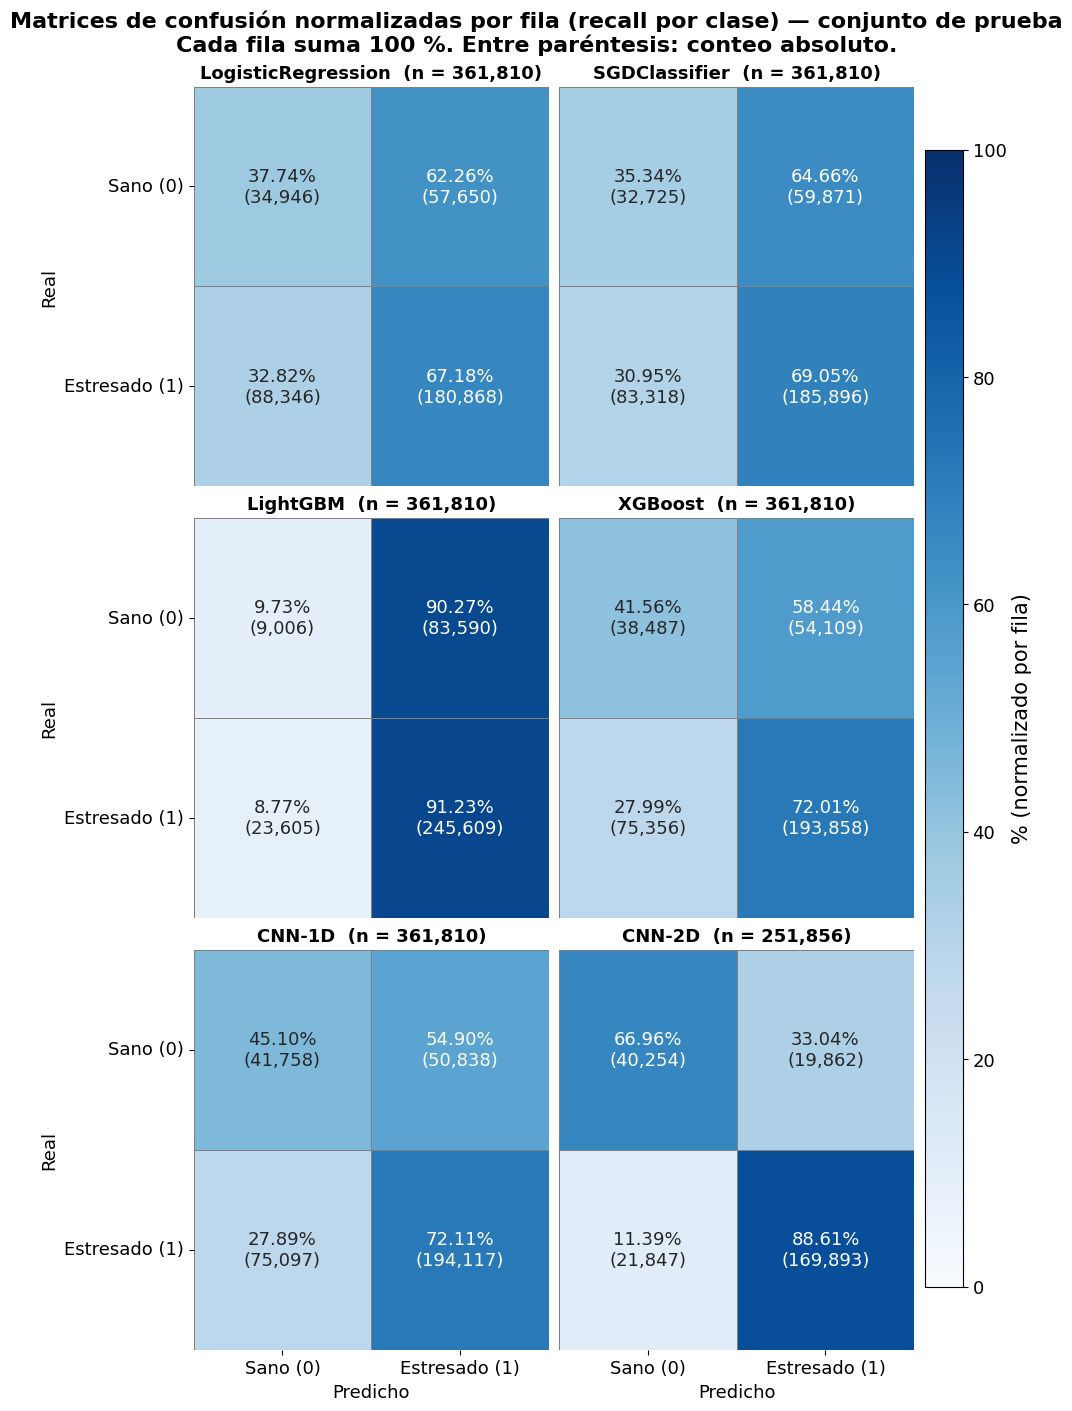

In [20]:
MODEL_GRID = [
    ["LogisticRegression", "SGDClassifier"],
    ["LightGBM",           "XGBoost"],
    ["CNN-1D",             "CNN-2D"],
]

fig, axes = plt.subplots(3, 2, figsize=(10, 14), constrained_layout=True)

for row_idx, row_models in enumerate(MODEL_GRID):
    for col_idx, m in enumerate(row_models):
        ax = axes[row_idx, col_idx]
        cm_abs = cms_abs[m]
        cm_pct = cms_row[m]
        n_eval  = len(all_ytrue[m])

        annot = np.empty((2, 2), dtype=object)
        for r in range(2):
            for c in range(2):
                annot[r, c] = f"{cm_pct[r, c]:.2f}%\n({cm_abs[r, c]:,})"

        show_x = (row_idx == 2)   # only bottom row
        show_y = (col_idx == 0)   # only left column

        sns.heatmap(
            cm_pct, ax=ax, annot=annot, fmt="", cmap="Blues",
            vmin=0, vmax=100,
            xticklabels=CLASS_LABELS if show_x else False,
            yticklabels=CLASS_LABELS if show_y else False,
            linewidths=0.5, linecolor="gray",
            cbar=False, annot_kws={"size": 13},
        )
        ax.set_title(f"{m}  (n = {n_eval:,})", fontsize=13, fontweight="bold")
        ax.set_ylabel("Real" if col_idx == 0 else "", fontsize=13)
        ax.set_xlabel("Predicho" if row_idx == 2 else "", fontsize=13)
        if show_y:
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=13)
        if show_x:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=13)

norm = mpl.colors.Normalize(vmin=0, vmax=100)
sm   = mpl.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, 1], orientation="vertical",
                    shrink=0.9, pad=0.03, aspect=30)
cbar.set_label("% (normalizado por fila)", fontsize=15)
cbar.ax.tick_params(labelsize=13)
fig.suptitle(
    "Matrices de confusión normalizadas por fila (recall por clase) — conjunto de prueba\n"
    "Cada fila suma 100 %. Entre paréntesis: conteo absoluto.",
    fontsize=16, fontweight="bold",
)
for ext in ("png", "pdf"):
    fig.savefig(FIGS_CM / f"confusion_matrices_pct.{ext}", dpi=300, bbox_inches="tight")
    # print(f"Saved: {FIGS_CM / f'confusion_matrices_pct.{ext}'")
plt.show()


### 6.2 Tabla de reducción de píxeles evaluables

In [21]:
from spectralcrop.evaluation.confusion_matrices import describe_evaluable_pixels_2d

n_total = len(all_ytrue["LogisticRegression"])
n_2d    = len(y_test2d)

pixel_table = describe_evaluable_pixels_2d(n_ml=n_total, n_2d=n_2d, patch_size=PATCH)
print(pixel_table.to_string(index=False))
print(f"\nExcluidos CNN-2D: {n_total - n_2d:,} px  ({(n_total-n_2d)/n_total*100:.2f}%)")
pixel_table.to_csv(FIGS_CM / "pixel_reduction_table.csv", index=False)


                      Arquitectura  Pixeles evaluados Pct vs ML                                                                                 Razon
ML (LR / SGD / LightGBM / XGBoost)             361810   100.00%                          Vector plano — todos los píxeles válidos del split de prueba
                            CNN-1D             361810   100.00%                          Vector plano — todos los píxeles válidos del split de prueba
                            CNN-2D             251856    69.61% Parches 5×5: excluye ~2 px del borde de cada parcela y píxeles con NaN en la vecindad

Excluidos CNN-2D: 109,954 px  (30.39%)


### 6.3 Tabla resumen CSV + Markdown

In [22]:
rows = []
for m in MODEL_ORDER:
    cm = cms_abs[m]; cr = cms_row[m]
    pr  = average_precision_score(all_ytrue[m], all_probs[m])
    roc = roc_auc_score(all_ytrue[m], all_probs[m])
    rows.append({"Modelo": m, "N_test": len(all_ytrue[m]),
                 "TN": int(cm[0,0]), "FP": int(cm[0,1]),
                 "FN": int(cm[1,0]), "TP": int(cm[1,1]),
                 "TNR (recall_0) %": round(cr[0,0], 2),
                 "FPR %": round(cr[0,1], 2),
                 "FNR %": round(cr[1,0], 2),
                 "TPR (recall_1) %": round(cr[1,1], 2),
                 "PR-AUC": round(pr, 4), "ROC-AUC": round(roc, 4)})

df_cm = pd.DataFrame(rows)
df_cm.to_csv(FIGS_CM / "confusion_matrices_pct_summary.csv", index=False)
md_lines = [
    "# Matrices de confusión normalizadas — Corrección C #16", "",
    "Normalización por fila (recall por clase). Cada fila suma 100 %.", "",
    df_cm.to_markdown(index=False),
]
(FIGS_CM / "confusion_matrices_pct_summary.md").write_text("\n".join(md_lines), encoding="utf-8")
print("Summary saved.")
df_cm


Summary saved.


,Modelo,N_test,TN,FP,FN,TP,TNR (recall_0) %,FPR %,FNR %,TPR (recall_1) %,PR-AUC,ROC-AUC
0,LogisticRegression,361810,34946,57650,88346,180868,37.74,62.26,32.82,67.18,0.7902,0.5526
1,SGDClassifier,361810,32725,59871,83318,185896,35.34,64.66,30.95,69.05,0.7885,0.5505
2,LightGBM,361810,9006,83590,23605,245609,9.73,90.27,8.77,91.23,0.7824,0.5445
3,XGBoost,361810,38487,54109,75356,193858,41.56,58.44,27.99,72.01,0.8236,0.6151
4,CNN-1D,361810,41758,50838,75097,194117,45.10,54.90,27.89,72.11,0.8341,0.6355
5,CNN-2D,251856,40254,19862,21847,169893,66.96,33.04,11.39,88.61,0.9635,0.8889
